In [18]:
import torch
import torch.nn as nn
import numpy as np

# 示例数据（APT攻击步骤序列）
sequences_name = [
    "reconnaissance",
    "data_exfiltration",
    "exploitation",
    "lateral_movement",
    "privilege_escalation",
    "lateral_movement",
]

sequences = [
    [1,3,5,2],  # 攻击链1: 侦察->漏洞利用->横向移动->数据渗出
    [1,4,2],    # 攻击链2: 侦察->权限提升->数据渗出
    [3,5,4,2]   # 攻击链3: 漏洞利用->横向移动->权限提升->数据渗出
]

# 超参数
EMBED_DIM = 64
HIDDEN_DIM = 128
N_NODES = 6  # 总共有5种攻击步骤+1个终止符

class CausalityLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(N_NODES, EMBED_DIM)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, N_NODES)
        
    def forward(self, x):
        embedded = self.embed(x)
        lstm_out, _ = self.lstm(embedded)
        logits = self.fc(lstm_out[:, -1, :])  # 预测下一步
        return logits

# 数据预处理
def create_dataset(seqs, seq_length=3):
    X, y = [], []
    for seq in seqs:
        for i in range(len(seq)-seq_length):
            X.append(seq[i:i+seq_length])
            y.append(seq[i+seq_length])
    return torch.LongTensor(X), torch.LongTensor(y)

X_train, y_train = create_dataset(sequences)

# 训练LSTM模型
model = CausalityLSTM()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1)%10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

# 提取因果概率矩阵
def get_causality_matrix(model, node_num=N_NODES):
    causality_mat = np.zeros((node_num, node_num))
    
    for src in range(node_num):
        test_seq = torch.LongTensor([[src]*3])  # 构建测试序列
        with torch.no_grad():
            pred = model(test_seq).softmax(dim=1).numpy()
        
        for dst in range(node_num):
            causality_mat[src][dst] = pred[0][dst]
    
    return causality_mat

causality_matrix = get_causality_matrix(model)
print("Causal Probability Matrix:\n", causality_matrix)

Epoch 10, Loss: 0.7128
Epoch 20, Loss: 0.0505
Epoch 30, Loss: 0.0047
Epoch 40, Loss: 0.0015
Epoch 50, Loss: 0.0009
Epoch 60, Loss: 0.0007
Epoch 70, Loss: 0.0006
Epoch 80, Loss: 0.0006
Epoch 90, Loss: 0.0006
Epoch 100, Loss: 0.0005
Causal Probability Matrix:
 [[1.56508386e-01 1.48382857e-01 2.98107803e-01 1.47446066e-01
  1.16237722e-01 1.33317217e-01]
 [1.08070276e-03 6.06724527e-04 9.96166646e-01 8.30705452e-04
  7.20165903e-04 5.95100340e-04]
 [1.27228573e-01 1.62630931e-01 2.93017179e-01 1.47498995e-01
  1.13465048e-01 1.56159386e-01]
 [1.13867305e-03 5.47130709e-04 9.96123612e-01 6.86256273e-04
  8.91863136e-04 6.12418458e-04]
 [1.65374877e-04 1.26670900e-04 9.99254286e-01 1.51349799e-04
  1.52225723e-04 1.49968051e-04]
 [1.16328825e-04 7.17368312e-05 9.99545157e-01 8.86265989e-05
  9.16033823e-05 8.65522670e-05]]


In [8]:
import gymnasium as gym
import gymnasium.spaces as spaces

class APTGraphEnv(gym.Env):
    def __init__(self, causality_matrix):
        super().__init__()
        self.causality = causality_matrix
        self.n_nodes = causality_matrix.shape[0]
        
        # 动作空间：选择两个节点建立边
        self.action_space = spaces.MultiDiscrete([self.n_nodes, self.n_nodes])
        
        # 状态空间：当前图的邻接矩阵
        self.observation_space = spaces.Box(
            low=0, high=1, 
            shape=(self.n_nodes, self.n_nodes),
            dtype=np.float32
        )
        
        self.reset()
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 明确指定dtype为float32
        self.graph = np.zeros((self.n_nodes, self.n_nodes), dtype=np.float32)
        return self.graph.copy(), {}
    
    def step(self, action):
        src, dst = action
        reward = 0
        
        # 禁止自循环
        if src == dst:
            return self.graph.copy(), -1, False, False, {}
        
        # 如果边不存在则添加
        if self.graph[src][dst] == 0:
            causal_prob = self.causality[src][dst]
            reward = causal_prob - 0.2
            
            self.graph[src][dst] = np.float32(1)
        else:
            reward = -0.5
        
        # 将done改为terminated
        terminated = bool(self.graph.sum() == self.n_nodes*(self.n_nodes-1))
        truncated = False  # 这里我们不使用截断
        
        return self.graph.copy(), reward, terminated, truncated, {}

In [9]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 初始化环境
env = APTGraphEnv(causality_matrix)
check_env(env)  # 验证环境符合规范

# 策略网络架构
policy_kwargs = dict(
    net_arch=[dict(pi=[128, 128], vf=[128, 128])]
)

# 创建PPO智能体
model = PPO(
    "MlpPolicy", 
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    n_steps=2048,
    batch_size=64,
    learning_rate=3e-4
)

# 训练
model.learn(total_timesteps=100000)

# 生成最终因果图
final_graph = env.graph
print("Generated Causal Graph:\n", final_graph)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


f:\python3\Lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 152      |
|    ep_rew_mean     | -74.4    |
| time/              |          |
|    fps             | 1301     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 142         |
|    ep_rew_mean          | -68.6       |
| time/                   |             |
|    fps                  | 930         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009105403 |
|    clip_fraction        | 0.0792      |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.58       |
|    explained_variance   | -0.0673     |
|    learning_rate        | 0.

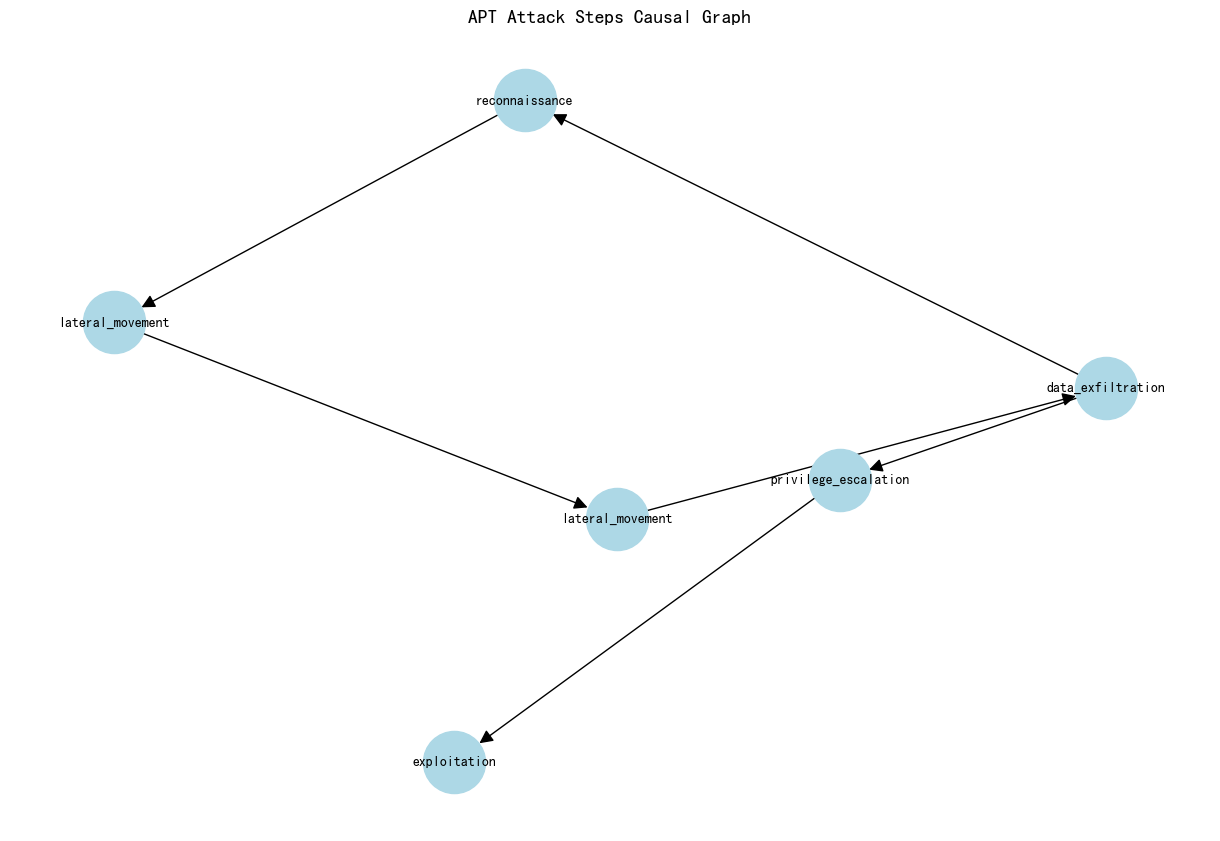

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

# 创建有向图
G = nx.DiGraph()

# 节点名称映射
node_names = sequences_name

# 添加节点和节点名称
n_nodes = final_graph.shape[0]
nodes = list(range(n_nodes))
G.add_nodes_from(nodes)

# 添加边
edges = [(i, j) for i in range(n_nodes) for j in range(n_nodes) if final_graph[i][j] > 0]
G.add_edges_from(edges)

# 绘制图形
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1.5, seed=42)  # 设置随机种子以固定布局

# 绘制节点和边
nx.draw(G, pos, with_labels=False, node_color='lightblue', 
        node_size=2000, arrowsize=20)

# 添加节点标签
labels = {i: name for i, name in enumerate(node_names) if i in nodes}  # 确保标签键存在于图中
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family='SimHei')

plt.title("APT Attack Steps Causal Graph", fontsize=14, fontfamily='SimHei')
plt.show()


In [ ]:
# 拓扑指标
def evaluate_graph(true_adj, pred_adj):
    # 计算精确率、召回率
    TP = np.sum((true_adj == 1) & (pred_adj == 1))
    FP = np.sum((true_adj == 0) & (pred_adj == 1))
    FN = np.sum((true_adj == 1) & (pred_adj == 0))
    
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    return precision, recall

In [ ]:
# 因果一致性
def causal_consistency(graph, causality_mat, threshold=0.6):
    valid_edges = graph.nonzero()
    scores = [causality_mat[i][j] for i,j in zip(*valid_edges)]
    return np.mean(scores) > threshold

